# GPT-1 Embedding Matrix
Load GPT-1 (OpenAI GPT) and retrieve its token embedding matrix.

In [5]:
from transformers import AutoModel
import torch
model_name = "openai-gpt"
model = AutoModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

OpenAIGPTModel LOAD REPORT from: openai-gpt
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
embedding_matrix = model.get_input_embeddings().weight.detach()
print("embedding_matrix shape:", tuple(embedding_matrix.shape))


embedding_matrix shape: (40478, 768)


In [10]:
sums = embedding_matrix.sum(dim=1)
centerned_matrix = embedding_matrix - embedding_matrix.mean(dim=0)

In [8]:
# SVD of the centered embedding matrix
# centerned_matrix shape: [vocab_size, hidden_size]
U, S, Vh = torch.linalg.svd(centerned_matrix, full_matrices=False)
centerned_matrix
print("U shape:", tuple(U.shape))
print("S shape:", tuple(S.shape))
print("Vh shape:", tuple(Vh.shape))


U shape: (40478, 768)
S shape: (768,)
Vh shape: (768, 768)


In [9]:
print(S)

tensor([93.5741, 73.4932, 71.5954, 61.6775, 50.9036, 49.4209, 45.5081, 43.6831,
        41.5174, 41.1091, 39.7847, 38.1260, 37.1237, 36.1202, 35.0367, 34.4477,
        33.7043, 33.3885, 32.2107, 31.7754, 31.4650, 31.1631, 30.8147, 30.6682,
        30.3715, 30.2412, 29.7929, 29.6071, 29.4998, 29.2430, 29.0667, 28.8959,
        28.8033, 28.5825, 28.3843, 28.0615, 27.8940, 27.8219, 27.4885, 27.4288,
        27.0634, 26.9847, 26.8903, 26.6904, 26.6533, 26.5948, 26.5372, 26.2831,
        26.1969, 26.1034, 25.9835, 25.9079, 25.8367, 25.6698, 25.6494, 25.5552,
        25.4332, 25.3367, 25.2446, 25.1827, 25.1052, 25.0336, 25.0106, 24.9729,
        24.9093, 24.7297, 24.6490, 24.6323, 24.5406, 24.5244, 24.4130, 24.3468,
        24.2967, 24.2694, 24.2218, 24.1609, 24.1036, 24.0211, 23.9867, 23.9484,
        23.8774, 23.8606, 23.7840, 23.7574, 23.7184, 23.6676, 23.6084, 23.5780,
        23.5645, 23.4969, 23.4692, 23.4246, 23.4106, 23.3415, 23.3335, 23.2455,
        23.2278, 23.1766, 23.1339, 23.07

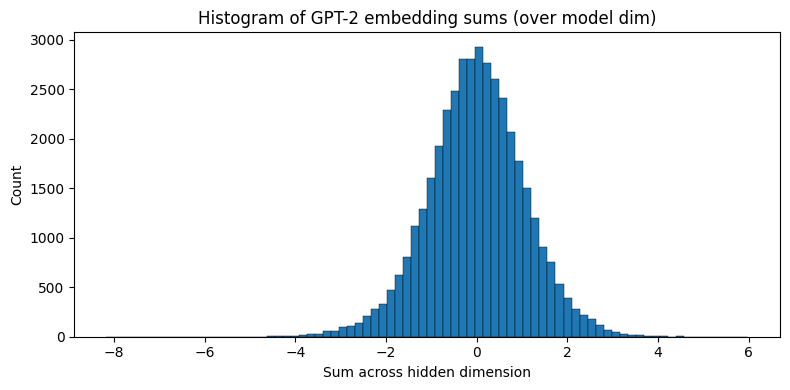

In [11]:
import matplotlib.pyplot as plt

vals = sums

plt.figure(figsize=(8, 4))
plt.hist(vals, bins=80, edgecolor="black", linewidth=0.3)
# plt.yscale("log")
plt.title("Histogram of GPT-2 embedding sums (over model dim)")
plt.xlabel("Sum across hidden dimension")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

class Block(nn.Module):
    def __init__(self, n_positions, config, scale=False):
        super().__init__()
        nx = config.n_embd
        self.attn = Attention(nx, n_positions, config, scale)
        self.ln_1 = nn.LayerNorm(nx, eps=config.layer_norm_epsilon)
        self.mlp = MLP(4 * nx, config)
        self.ln_2 = nn.LayerNorm(nx, eps=config.layer_norm_epsilon)

    def forward(self, x, attention_mask=None, output_attentions=False):
        attn_outputs = self.attn(
            x,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
        )
        a = attn_outputs[0]

        n = self.ln_1(x + a)
        m = self.mlp(n)
        h = self.ln_2(n + m)

        outputs = [h] + attn_outputs[1:]
        return outputs

never normed attn-out

We can test by training a post norm transformer